🌍 AI / ML for Atmospheric Science
ERA5 2m Temperature over India using Python & CNN

🎯 Notebook Objective

1.   Basic Python concepts required for Machine Learning
2.   How ERA5 climate data is structured
3.   How to visualize temperature scientifically
4.   How to prepare climate data for ML
5. How a CNN learns spatial weather patterns
6. How to evaluate predictions over India















✅**PART1** PYTHON BASICS FOR ML


🐍 Why Python for Climate & ML?

1. Python is used because it has:

2. Libraries for climate data (xarray)

3. Libraries for ML & AI (scikit-learn, PyTorch)

4. Excellent visualization tools

2️⃣ Variables & Data Types

In [1]:
# Integer
days = 30

# Float
temperature = 28.5

# String
region = "India"

# Boolean
is_hot = True


👉 Why this matters for ML?

ML models work with numbers

Strings are only for labels / metadata

3️⃣ Lists & Arrays

In [2]:
temps = [28.1, 29.5, 30.2, 31.0]

In [3]:
import numpy as np
temps_array = np.array(temps)
temps_array


array([28.1, 29.5, 30.2, 31. ])

👉 Why NumPy?

ML models need fast numerical arrays

Climate data is always numerical

4️⃣ Loops & Conditions

In [4]:
for t in temps:
    if t > 30:
        print("Hot day:", t)


Hot day: 30.2
Hot day: 31.0


👉 Why this matters?

Used in training loops

Used in data processing

5️⃣ Functions (VERY IMPORTANT)

In [5]:
def kelvin_to_celsius(T):
    return T - 273.15


In [6]:
kelvin_to_celsius(300)

26.850000000000023

✅**PART2** LIBRARIES FOR CLIMATE & ML

📦 6. Import Required Libraries

In [5]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split


## 👉 Why these libraries?

| Library     | Purpose                  |
|------------|--------------------------|
| xarray     | Climate data handling    |
| NumPy      | Numerical operations     |
| Matplotlib | Scientific plots         |
| PyTorch    | Deep Learning            |


✅**PART3** ERA5 DATA HANDLING

🌍 7. Load ERA5 Dataset

In [3]:
!wget "https://drive.usercontent.google.com/download?id=1AqHvrkZtVGFq7MYY3wWocMASXbaM3H5Q&export=download" -O data_stream-mnth_stepType-avgua.nc

--2026-01-22 09:39:38--  https://drive.usercontent.google.com/download?id=1AqHvrkZtVGFq7MYY3wWocMASXbaM3H5Q&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 192.178.155.132, 2607:f8b0:4004:c08::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|192.178.155.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1613444 (1.5M) [application/octet-stream]
Saving to: ‘data_stream-mnth_stepType-avgua.nc’

data_stream-mnth_st 100%[===================>]   1.54M  --.-KB/s    in 0.04s   

2026-01-22 09:39:41 (43.3 MB/s) - ‘data_stream-mnth_stepType-avgua.nc’ saved [1613444/1613444]



In [6]:
ds = xr.open_dataset("data_stream-mnth_stepType-avgua.nc")
ds


<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 72, latitude: 117, longitude: 117)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 576B 2024-01-01 ... 2024-03-01T23...
  * latitude    (latitude) float64 936B 37.0 36.75 36.5 36.25 ... 8.5 8.25 8.0
  * longitude   (longitude) float64 936B 68.0 68.25 68.5 ... 96.5 96.75 97.0
    number      int64 8B ...
    expver      (valid_time) <U4 1kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-21T20:26 GRIB to CDM+CF via cfgrib-0.9.1...

## 8️⃣ Understanding the Dataset (CRITICAL)

### Dataset structure:

- **valid_time** → time steps (72)
- **latitude × longitude** → India grid (117 × 117)
- **t2m** → 2m air temperature (Kelvin)

> This is **gridded climate data**, not station data.


🌡️ 9. Convert Kelvin → Celsius

In [12]:
ds["t2m_c"] = ds["t2m"] - 273.15
ds["t2m_c"].attrs["units"] = "°C"


## 👉 Why this step?

- ERA5 stores temperature in **Kelvin**
- Humans understand **Celsius**
- ML models don’t care — **scientists do**


✅**PART4** VISUALIZATION & COLORMAPS

## 🎨 10. Why Colormaps Matter

- Colors represent **physical meaning**
- Wrong colormap → **wrong interpretation**

### Temperature convention:
- **Blue** → Cold  
- **Red** → Hot


🗺️ 11. Plot Temperature over India

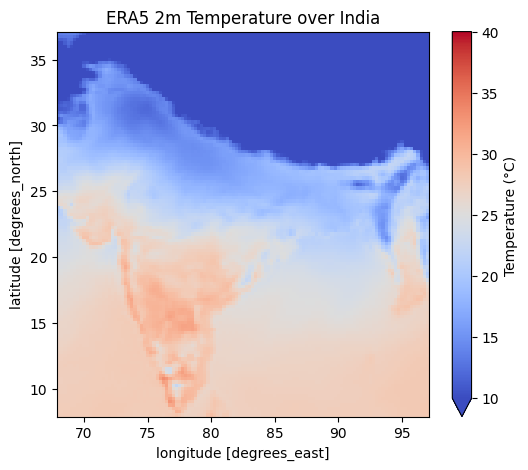

In [13]:
plt.figure(figsize=(6,5))
ds["t2m_c"].isel(valid_time=10).plot(
    cmap="coolwarm",
    vmin=10,
    vmax=40,
    cbar_kwargs={"label": "Temperature (°C)"}
)
plt.title("ERA5 2m Temperature over India")
plt.show()


## 👉 Why vmin / vmax?

- Ensures **fair comparison across time**
- Essential for **climate analysis**


✅**PART5** PREPARING DATA FOR ML

## 🔧 12. Why Normalization is Required

- ML models train better when data is between **0 and 1**


In [14]:
tmin = ds["t2m_c"].min()
tmax = ds["t2m_c"].max()

data = (ds["t2m_c"] - tmin) / (tmax - tmin)


## 🧪 13. Create Input–Output Pairs

### ML Task:
- Predict temperature at the **next time step**


In [15]:
X = data.isel(valid_time=slice(0, -1)).values
y = data.isel(valid_time=slice(1, None)).values


✂️ 14. Train–Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


👉 Why split?

Train → learn patterns

Test → check generalization

✅**PART6** CNN MODEL

## 🧠 15. Why CNN for Climate?

CNNs are good at:

- Learning **spatial patterns**
- Recognizing **weather structures**


📦 16. PyTorch Dataset

In [19]:
class ClimateDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


🚚 17. DataLoaders

In [20]:
train_loader = DataLoader(
    ClimateDataset(X_train, y_train),
    batch_size=4,
    shuffle=True
)

test_loader = DataLoader(
    ClimateDataset(X_test, y_test),
    batch_size=4
)


🧩 18. CNN Architecture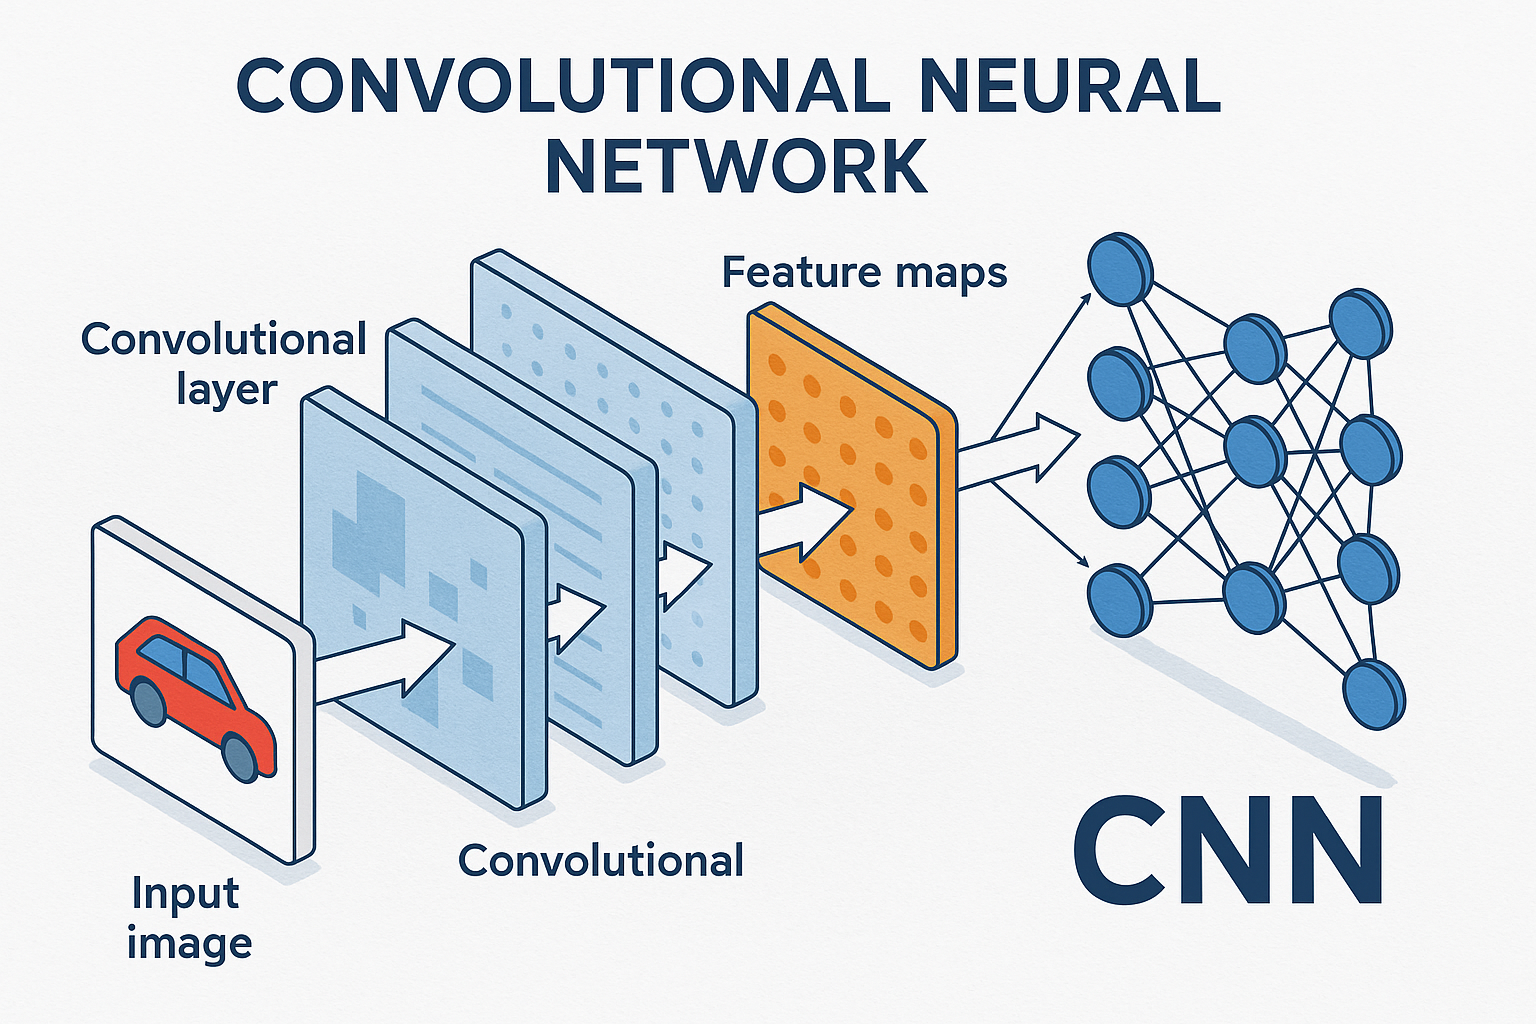

In [21]:
class ClimateCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


👉 What CNN learns:

Filters → spatial gradients

Hidden patterns → weather features

🏋️ 19. Train the CNN

In [22]:
model = ClimateCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


In [23]:
for epoch in range(5):
    model.train()
    losses = []

    for xb, yb in train_loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    print(f"Epoch {epoch+1}, Loss: {np.mean(losses):.4f}")


Epoch 1, Loss: 0.0748
Epoch 2, Loss: 0.0141
Epoch 3, Loss: 0.0060
Epoch 4, Loss: 0.0034
Epoch 5, Loss: 0.0027


✅**PART7** EVALUATION & PLOTS

🔮 20. Make Predictions

In [24]:
model.eval()
xb, yb = next(iter(test_loader))
pred = model(xb).detach().numpy()


### Why did we convert `tmin` and `tmax` to float?

- `xarray.DataArray` carries dimensions and coordinates
- ML predictions are plain NumPy arrays
- Mixing them causes broadcasting errors
- Converting to float removes metadata and keeps only the value

**Rule of thumb:**  
👉 *xarray for science, NumPy for ML*


In [29]:
tmin_val = float(tmin.values)
tmax_val = float(tmax.values)

In [30]:
pred_denorm = pred * (tmax_val - tmin_val) + tmin_val
true_denorm = yb.numpy() * (tmax_val - tmin_val) + tmin_val


## Why Do We Need Accuracy Assessment?

Training a model is not enough.

We must answer:
- How wrong is the model?
- Is the error acceptable physically?
- Does the model generalize to unseen data?

In climate science, **small errors can have large impacts**.


📐 1. Compute Error Metrics
Flatten spatial grids (important!)

In [31]:
y_true = true_denorm.flatten()
y_pred = pred_denorm.flatten()


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"MAE  : {mae:.2f} °C")
print(f"RMSE : {rmse:.2f} °C")
print(f"R²   : {r2:.3f}")


MAE  : 1.99 °C
RMSE : 13.51 °C
R²   : 0.952


### Understanding the Metrics

**MAE (Mean Absolute Error)**  
- Average temperature error
- Easy to interpret physically
- Example: MAE = 1.5°C → model is wrong by ~1.5°C on average

**RMSE (Root Mean Square Error)**  
- Penalizes large errors more
- Sensitive to extremes (heatwaves, cold spells)

**R² Score**  
- Measures how much variance the model explains
- R² = 1 → perfect
- R² = 0 → no skill


📊 2. Predicted vs Actual Plot (India-wide)

Your true_denorm and pred_denorm are NumPy arrays.
To plot like ERA5, we must wrap them back into xarray.DataArray with lat/lon.

In [36]:
# Choose one test sample (e.g., first)
i = 0

# Create xarray DataArray for ACTUAL
actual_xr = xr.DataArray(
    true_denorm[i],
    coords={
        "latitude": ds.latitude,
        "longitude": ds.longitude
    },
    dims=["latitude", "longitude"],
    name="Actual Temperature"
)

# Create xarray DataArray for PREDICTED
pred_xr = xr.DataArray(
    pred_denorm[i],
    coords={
        "latitude": ds.latitude,
        "longitude": ds.longitude
    },
    dims=["latitude", "longitude"],
    name="Predicted Temperature"
)


## 📌 Why this step is required

- `xarray.plot()` needs **coordinate-aware data**
- CNN outputs are just **numbers**, no geography
- We **reattach latitude & longitude**


Plot ACTUAL Temperature

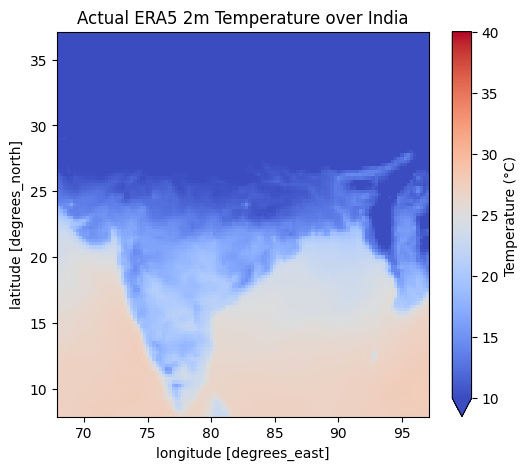

In [37]:
plt.figure(figsize=(6,5))
actual_xr.plot(
    cmap="coolwarm",
    vmin=10,
    vmax=40,
    cbar_kwargs={"label": "Temperature (°C)"}
)
plt.title("Actual ERA5 2m Temperature over India")
plt.show()


Plot PREDICTED Temperature

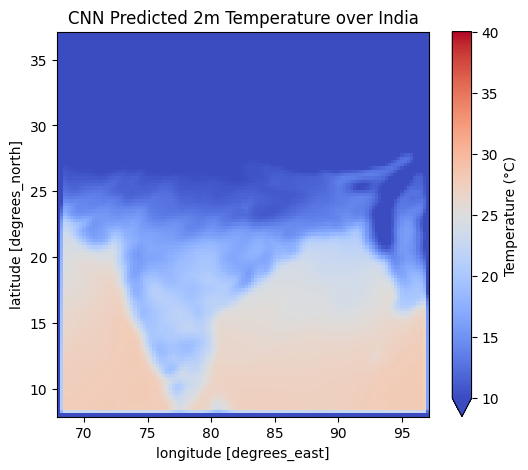

In [38]:
plt.figure(figsize=(6,5))
pred_xr.plot(
    cmap="coolwarm",
    vmin=10,
    vmax=40,
    cbar_kwargs={"label": "Temperature (°C)"}
)
plt.title("CNN Predicted 2m Temperature over India")
plt.show()


Side-by-Side Comparison

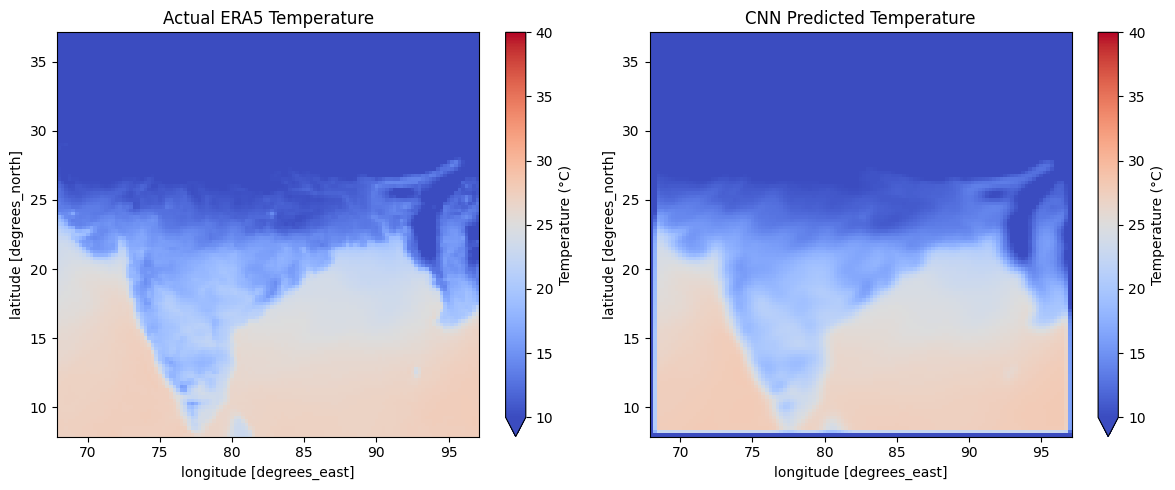

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

actual_xr.plot(
    ax=ax[0],
    cmap="coolwarm",
    vmin=10,
    vmax=40,
    cbar_kwargs={"label": "Temperature (°C)"}
)
ax[0].set_title("Actual ERA5 Temperature")

pred_xr.plot(
    ax=ax[1],
    cmap="coolwarm",
    vmin=10,
    vmax=40,
    cbar_kwargs={"label": "Temperature (°C)"}
)
ax[1].set_title("CNN Predicted Temperature")

plt.tight_layout()
plt.show()


### Why Error Maps Matter

- Shows **where** the model fails
- Mountains, coasts, deserts often have higher error
- Helps diagnose missing physics


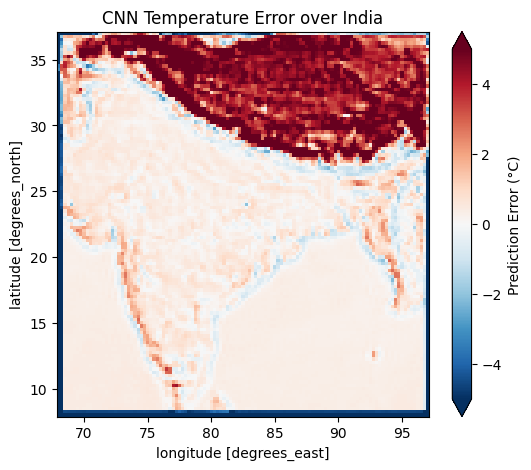

In [40]:
error_xr = pred_xr - actual_xr

plt.figure(figsize=(6,5))
error_xr.plot(
    cmap="RdBu_r",
    vmin=-5,
    vmax=5,
    cbar_kwargs={"label": "Prediction Error (°C)"}
)
plt.title("CNN Temperature Error over India")
plt.show()
